<div style="background: linear-gradient(135deg, #1a2a6c, #2c3e91); padding: 30px; border-radius: 12px; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 28px;">📡 Automatic Modulation Classification Engine</h1>
  <h3 style="margin: 8px 0 0 0; font-weight: 400; color: #dcdfff;">Using 1D Convolutional Neural Networks</h3>
  <p style="margin-top: 15px; font-size: 14px; color: #c9cdf7;">
    <b>Author:</b> R. M. S. H. Ratnayake &nbsp;|&nbsp; <b>Date:</b> August 2026
  </p>
</div>

<div style="background: #f4f6fb; padding: 20px; border-radius: 10px; margin-top: 15px; border-left: 5px solid #2c3e91;">
  <h3 style="color: #1a2a6c;">🎯 Overview</h3>
  <p style="font-size: 15px; line-height: 1.6;">
    This notebook implements an end-to-end deep learning pipeline for <b>Automatic Modulation Classification (AMC)</b>,
    classifying <b>11 analog and digital modulation schemes</b> directly from raw complex I/Q time-series samples.
    Unlike traditional likelihood-based or 2D image-based (spectrogram) approaches, this system uses a lightweight
    <b>1D CNN</b> to process <code>2 × N</code> I/Q tensors directly, reducing computational overhead while preserving
    phase and amplitude information critical for classification.
  </p>
</div>

<div style="background: #f4f6fb; padding: 20px; border-radius: 10px; margin-top: 15px; border-left: 5px solid #2c3e91;">
  <h3 style="color: #1a2a6c;">📋 Objectives</h3>
  <ul style="font-size: 15px; line-height: 1.8;">
    <li>Build a full pipeline to classify 11 modulation schemes using the <b>RadioML 2016.10A</b> benchmark dataset</li>
    <li>Implement a lightweight 1D CNN for raw complex I/Q inputs</li>
    <li>Evaluate accuracy across SNR levels from <b>−20 dB to +18 dB</b></li>
    <li>Apply <b>INT8 quantization</b> for low-latency, edge-deployable inference</li>
  </ul>
</div>

<div style="background: #f4f6fb; padding: 20px; border-radius: 10px; margin-top: 15px; border-left: 5px solid #2c3e91;">
  <h3 style="color: #1a2a6c;">🏗️ Model Architecture</h3>
  <table style="width: 100%; border-collapse: collapse; font-size: 14px; margin-top: 10px;">
    <tr style="background: #1a2a6c; color: white;">
      <th style="padding: 8px; text-align: left;">Layer</th>
      <th style="padding: 8px;">Kernel</th>
      <th style="padding: 8px;">Stride</th>
      <th style="padding: 8px;">Output Shape</th>
    </tr>
    <tr style="background: #e8eaf5;"><td style="padding: 8px;">Input Tensor</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">(2, 128)</td></tr>
    <tr><td style="padding: 8px;">Conv1D + BN + ReLU</td><td style="padding: 8px; text-align:center;">7</td><td style="padding: 8px; text-align:center;">1</td><td style="padding: 8px; text-align:center;">(64, 128)</td></tr>
    <tr style="background: #e8eaf5;"><td style="padding: 8px;">MaxPool1D</td><td style="padding: 8px; text-align:center;">2</td><td style="padding: 8px; text-align:center;">2</td><td style="padding: 8px; text-align:center;">(64, 64)</td></tr>
    <tr><td style="padding: 8px;">Conv1D + BN + ReLU</td><td style="padding: 8px; text-align:center;">5</td><td style="padding: 8px; text-align:center;">1</td><td style="padding: 8px; text-align:center;">(128, 64)</td></tr>
    <tr style="background: #e8eaf5;"><td style="padding: 8px;">MaxPool1D</td><td style="padding: 8px; text-align:center;">2</td><td style="padding: 8px; text-align:center;">2</td><td style="padding: 8px; text-align:center;">(128, 32)</td></tr>
    <tr><td style="padding: 8px;">Conv1D + BN + ReLU</td><td style="padding: 8px; text-align:center;">3</td><td style="padding: 8px; text-align:center;">1</td><td style="padding: 8px; text-align:center;">(256, 32)</td></tr>
    <tr style="background: #e8eaf5;"><td style="padding: 8px;">AdaptiveAvgPool1D</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">(256, 1)</td></tr>
    <tr><td style="padding: 8px;">Dense + Dropout(0.5)</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">(128)</td></tr>
    <tr style="background: #e8eaf5;"><td style="padding: 8px;">Dense Output</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">–</td><td style="padding: 8px; text-align:center;">(11)</td></tr>
  </table>
</div>

<div style="background: #eef7ee; padding: 20px; border-radius: 10px; margin-top: 15px; border-left: 5px solid #2e7d32;">
  <h3 style="color: #1a2a6c;">✅ Expected Deliverables</h3>
  <ol style="font-size: 15px; line-height: 1.8;">
    <li>Modular PyTorch pipeline (data loading, training, evaluation)</li>
    <li>Accuracy-vs-SNR performance curves (target &gt;90% at SNR ≥ 0 dB)</li>
    <li>Quantized ONNX model for edge deployment</li>
    <li>Documented experimental results</li>
  </ol>
</div>

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


### Loading the data

In [3]:
# Update this to the actual path on your machine
DATA_PATH = r"RML2016.10a_dict.dat"     # Windows example

with open(DATA_PATH, 'rb') as f:
    data_dict = pickle.load(f, encoding='latin1')  # latin1 needed — pickled in Python 2 originally

mod_types = sorted(set([k[0] for k in data_dict.keys()]))
snr_levels = sorted(set([k[1] for k in data_dict.keys()]))

print("Modulation classes:", mod_types)
print("SNR levels (dB):", snr_levels)
print("Sample shape per example:", data_dict[(mod_types[0], snr_levels[0])].shape)

Modulation classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels (dB): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Sample shape per example: (1000, 2, 128)


### Flatten into X, y, SNR arrays

In [4]:
X = []
y = []
snrs = []

for (mod, snr), samples in data_dict.items():
    X.append(samples)
    y += [mod] * samples.shape[0]
    snrs += [snr] * samples.shape[0]

X = np.vstack(X)              # shape: (220000, 2, 128)
y = np.array(y)
snrs = np.array(snrs)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Total samples:", X.shape[0])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X shape: (220000, 2, 128)
y shape: (220000,)
Total samples: 220000
Class mapping: {np.str_('8PSK'): np.int64(0), np.str_('AM-DSB'): np.int64(1), np.str_('AM-SSB'): np.int64(2), np.str_('BPSK'): np.int64(3), np.str_('CPFSK'): np.int64(4), np.str_('GFSK'): np.int64(5), np.str_('PAM4'): np.int64(6), np.str_('QAM16'): np.int64(7), np.str_('QAM64'): np.int64(8), np.str_('QPSK'): np.int64(9), np.str_('WBFM'): np.int64(10)}


### Energy Normalisation

In [5]:
def normalize_iq(X):
    # X shape: (N, 2, 128) -> normalize each sample to unit average power
    power = np.mean(X[:, 0, :]**2 + X[:, 1, :]**2, axis=1, keepdims=True)  # (N, 1)
    power = np.sqrt(power)[:, :, np.newaxis]  # (N, 1, 1) for broadcasting over both I and Q channels
    X_norm = X / power
    return X_norm

X_norm = normalize_iq(X)
print("Normalized X shape:", X_norm.shape)
print("Sample power check (should be ~1.0):", 
      np.mean(X_norm[0,0,:]**2 + X_norm[0,1,:]**2))

Normalized X shape: (220000, 2, 128)
Sample power check (should be ~1.0): 1.0


## Splitting the Data

In [6]:
from sklearn.model_selection import train_test_split

# Stratify by a combined class+SNR key so each split has balanced representation across both
strat_key = np.array([f"{yi}_{si}" for yi, si in zip(y_encoded, snrs)])

X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_norm, y_encoded, snrs, test_size=0.3, random_state=42, stratify=strat_key
)

strat_key_temp = np.array([f"{yi}_{si}" for yi, si in zip(y_temp, snr_temp)])
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, random_state=42, stratify=strat_key_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (154000, 2, 128) Val: (33000, 2, 128) Test: (33000, 2, 128)


## PyTorch Dataset and DataLoader

In [7]:
class RadioMLDataset(Dataset):
    def __init__(self, X, y, snrs):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.snrs = torch.tensor(snrs, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.snrs[idx]

train_ds = RadioMLDataset(X_train, y_train, snr_train)
val_ds   = RadioMLDataset(X_val, y_val, snr_val)
test_ds  = RadioMLDataset(X_test, y_test, snr_test)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Sanity check
xb, yb, sb = next(iter(train_loader))
print("Batch X:", xb.shape, "Batch y:", yb.shape, "Batch SNR:", sb.shape)

Batch X: torch.Size([256, 2, 128]) Batch y: torch.Size([256]) Batch SNR: torch.Size([256])


## 1D CNN model

In [16]:
class AMC_CNN1D_v2(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)          # new pooling stage

        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)  # new conv block
        self.bn4 = nn.BatchNorm1d(256)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.4)        # slightly lower dropout
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.gap(x).squeeze(-1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

In [18]:
model = AMC_CNN1D(num_classes=11).to(device)
print(model)

# Sanity check with a real batch
xb, yb, sb = next(iter(train_loader))
xb = xb.to(device)
out = model(xb)
print("Output shape:", out.shape)   # should be [256, 11]

AMC_CNN1D(
  (conv1): Conv1d(2, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=11, bias=True)
  (relu): ReLU()
)
Output shape: torch.Size([256, 11])


In [19]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 175,819
Trainable parameters: 175,819


### Loss, optimizer, and training loop

In [20]:
import time
from tqdm.notebook import tqdm  # use tqdm.auto if tqdm.notebook has issues locally

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for xb, yb, sb in loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb, sb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            
            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    
    return running_loss / total, correct / total

### CNN Model

In [21]:
NUM_EPOCHS = 60
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# Add early stopping so it doesn't run 60 epochs blindly
patience_counter = 0
early_stop_patience = 10
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_amc_cnn1d.pth")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

Epoch 1 | Train Acc: 0.4554 | Val Acc: 0.4969 | LR: 1.00e-03
Epoch 2 | Train Acc: 0.5076 | Val Acc: 0.5298 | LR: 1.00e-03
Epoch 3 | Train Acc: 0.5291 | Val Acc: 0.5375 | LR: 1.00e-03
Epoch 4 | Train Acc: 0.5436 | Val Acc: 0.5555 | LR: 1.00e-03
Epoch 5 | Train Acc: 0.5549 | Val Acc: 0.5627 | LR: 1.00e-03
Epoch 6 | Train Acc: 0.5622 | Val Acc: 0.5685 | LR: 1.00e-03
Epoch 7 | Train Acc: 0.5694 | Val Acc: 0.5733 | LR: 1.00e-03
Epoch 8 | Train Acc: 0.5732 | Val Acc: 0.5815 | LR: 1.00e-03
Epoch 9 | Train Acc: 0.5785 | Val Acc: 0.5846 | LR: 1.00e-03
Epoch 10 | Train Acc: 0.5817 | Val Acc: 0.5815 | LR: 1.00e-03
Epoch 11 | Train Acc: 0.5842 | Val Acc: 0.5835 | LR: 1.00e-03
Epoch 12 | Train Acc: 0.5872 | Val Acc: 0.5856 | LR: 1.00e-03
Epoch 13 | Train Acc: 0.5890 | Val Acc: 0.5929 | LR: 1.00e-03
Epoch 14 | Train Acc: 0.5905 | Val Acc: 0.5845 | LR: 1.00e-03
Epoch 15 | Train Acc: 0.5938 | Val Acc: 0.5879 | LR: 1.00e-03
Epoch 16 | Train Acc: 0.5955 | Val Acc: 0.5952 | LR: 1.00e-03
Epoch 17 | Train 

## Plot training curves

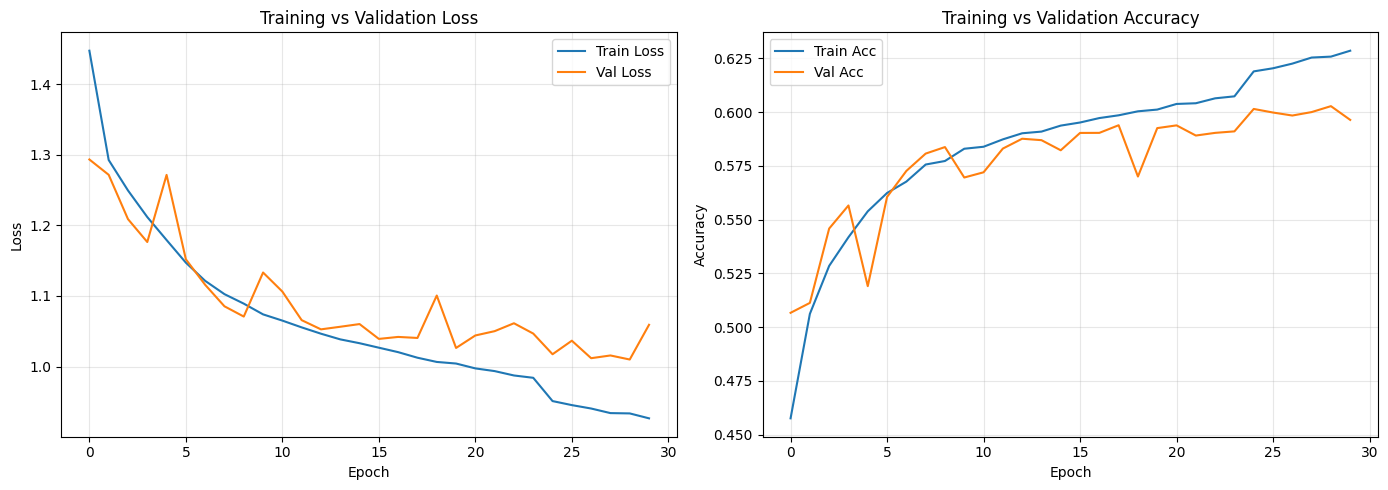

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
model.load_state_dict(torch.load("best_amc_cnn1d.pth"))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.9986 | Test Accuracy: 0.6084


### Accuracy vs SNR

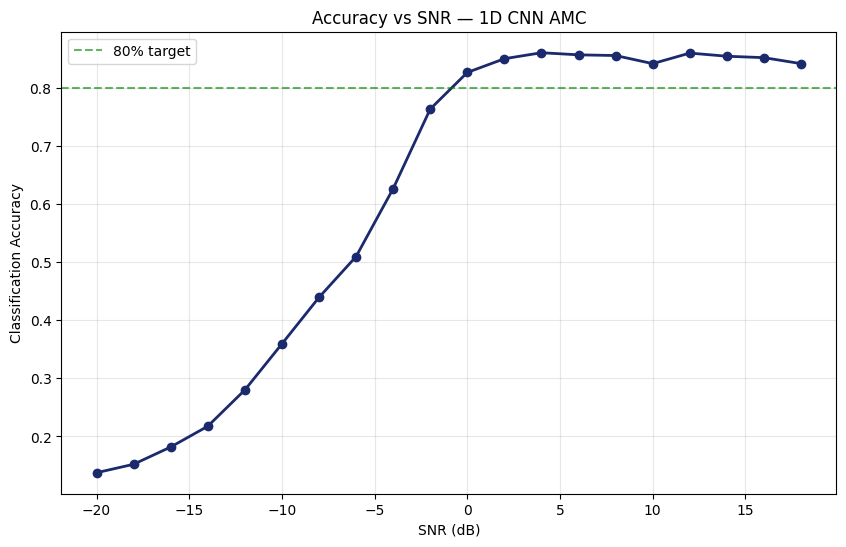

SNR  -20 dB: 0.1376
SNR  -18 dB: 0.1521
SNR  -16 dB: 0.1818
SNR  -14 dB: 0.2176
SNR  -12 dB: 0.2800
SNR  -10 dB: 0.3594
SNR   -8 dB: 0.4394
SNR   -6 dB: 0.5097
SNR   -4 dB: 0.6267
SNR   -2 dB: 0.7636
SNR    0 dB: 0.8267
SNR    2 dB: 0.8503
SNR    4 dB: 0.8606
SNR    6 dB: 0.8570
SNR    8 dB: 0.8558
SNR   10 dB: 0.8418
SNR   12 dB: 0.8600
SNR   14 dB: 0.8545
SNR   16 dB: 0.8521
SNR   18 dB: 0.8418


In [30]:
model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for xb, yb, sb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_snrs.extend(sb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_snrs = np.array(all_snrs)

snr_range = sorted(np.unique(all_snrs))
acc_per_snr = []

for snr in snr_range:
    mask = all_snrs == snr
    acc = (all_preds[mask] == all_labels[mask]).mean()
    acc_per_snr.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(snr_range, acc_per_snr, marker='o', linewidth=2, color='#1a2a6c')
plt.axhline(y=0.80, color='green', linestyle='--', alpha=0.6, label='80% target')
plt.xlabel('SNR (dB)')
plt.ylabel('Classification Accuracy')
plt.title('Accuracy vs SNR — 1D CNN AMC')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

for snr, acc in zip(snr_range, acc_per_snr):
    print(f"SNR {snr:4d} dB: {acc:.4f}")

### Confusion Matrix

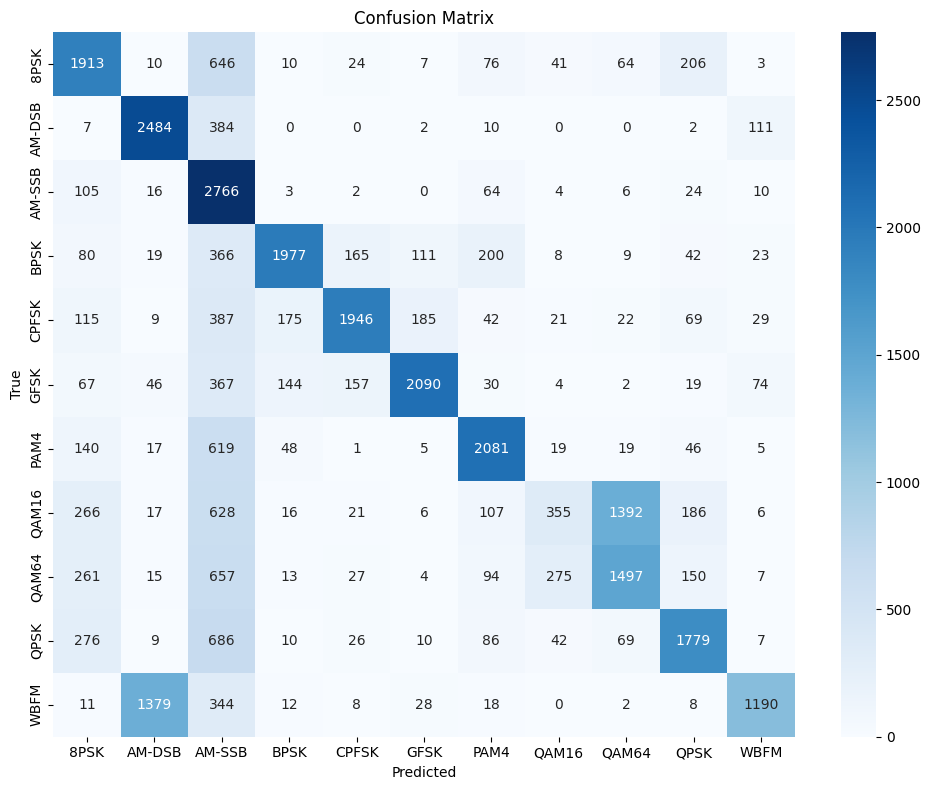

In [25]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()